In [2]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_PostProcessing
import XSpect.XSpect_Diagnostics

In [9]:
import h5py as h5
fh=h5.File(r'/sdf/data/lcls/ds/xcs/xcsl1004021/hdf5/smalldata/xcsl1004021_Run0085.h5')
epix=fh[r'epix_2/ROI_0_area']



In [11]:
summed=np.nansum(epix,axis=0)

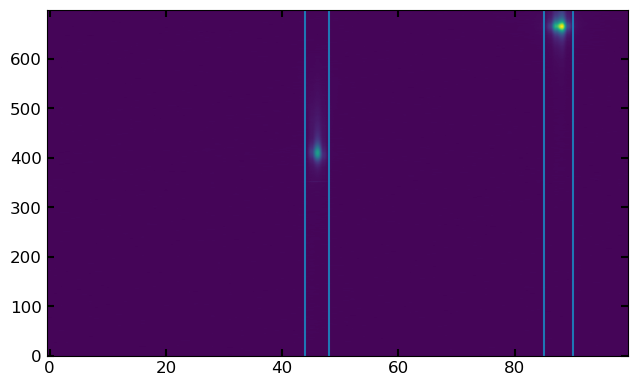

In [19]:
plt.imshow(summed,origin='lower',aspect='auto')
rois=[44,48,85,90]
for roi in rois:
    plt.axvline(roi)

In [24]:
start=time.time()
keys=['epics/ccm_E','epics/ccm_E_setpoint','tt/ttCorr','epics/lxt_ttc', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']
xes_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(lcls_run=21, hutch='xcs', experiment_id='xcsl1004021')
xes = XSpect.XSpect_Controller.XESBatchAnalysisRotation()
xes.key_epix=[r'epix_2/ROI_0_area']
xes.friendly_name_epix=['epix']
xes.set_key_aliases(keys,names)
# Time binds
xes.mintime=-2
xes.maxtime=10
xes.numpoints=240
xes.time_bins=np.linspace(xes.mintime,xes.maxtime,xes.numpoints)
# K alpha ROI
xes.rois=[[44,48],[85,90]]
xes.adu_cutoff=3.0
# Filters
xes.add_filter('xray','ipm',2.0E3)
xes.add_filter('simultaneous','ipm',2.0E3)
xes.add_filter('simultaneous','time_tool_ampl',0.05)
# Runs
xes.run_parser(['85-87'])
stop=time.time()

In [25]:
start=time.time()
xes.primary_analysis_parallel_range(4,xes_experiment,increment=2000,verbose=False)
bend=time.time()

Processing: 100%|██████████| 45/45 [03:59<00:00,  5.33s/Shot_Batch]


In [ ]:
xes.analyzed_runs[0].epix_xray_not_laser_time_binned_ROI_1

(-0.5, 2.0)

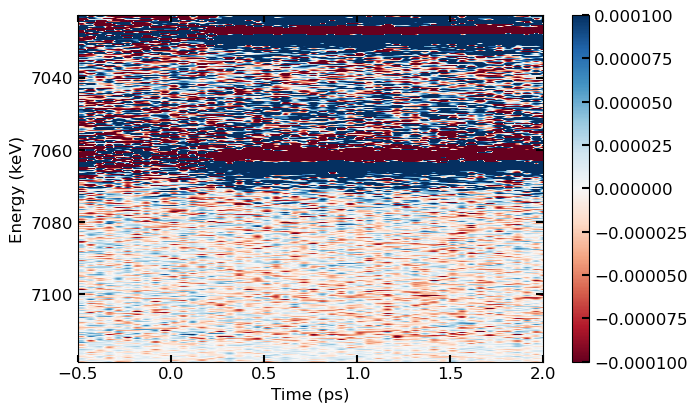

In [29]:
v=XSpect.XSpect_Visualization.XESVisualization()
v.combine_spectra(xes_analysis=xes,
                  xes_key='epix_xray_not_laser_time_binned_ROI_1',
                  xes_laser_key='epix_simultaneous_laser_time_binned_ROI_1')
v.vmin=-0.0001
v.vmax=0.0001
v.plot_2d_difference_spectrum(xes)
plt.xlim(-0.5,2.0)

In [4]:
np.shape(xas.summed_norm_on)

(240, 90)

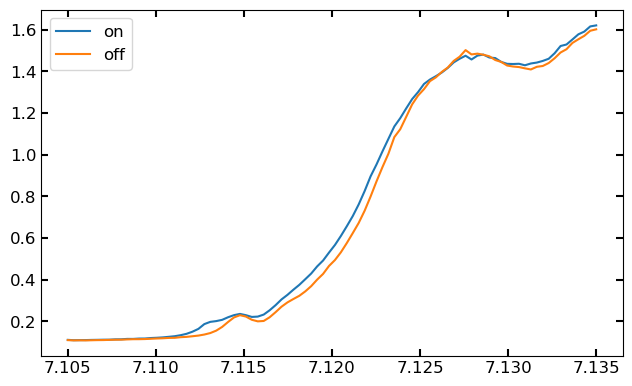

In [5]:
plt.plot(xas.ccm_bins,np.nansum(xas.summed_laser_on,axis=0)/np.nansum(xas.summed_norm_on,axis=0))
plt.plot(xas.ccm_bins,np.nansum(xas.summed_laser_off,axis=0)/np.nansum(xas.summed_norm_off,axis=0))
plt.legend(['on','off'])

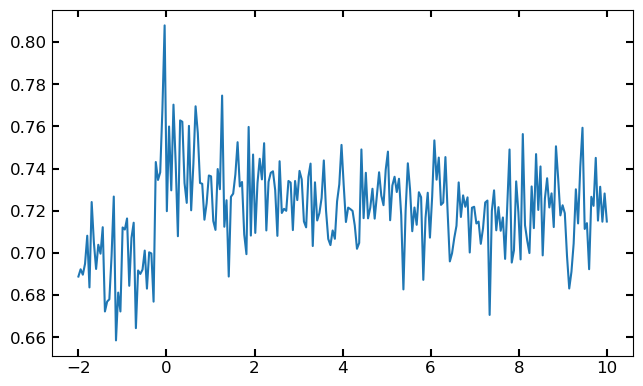

In [8]:
plt.plot(xas.time_bins,np.nansum(xas.summed_laser_on,axis=1)/np.nansum(xas.summed_norm_on,axis=1))